## 12.1 Least Squares as an Optimization Problem

In [Lecture 11](https://colab.research.google.com/drive/1G1pD7FmlPoEKxUcmZfLeScoDZXrst7qe?usp=sharing) we used scikit-learn to find an approximate solution to $\mathbf{X}\boldsymbol{{\beta}} = \mathbf{y}$ by running the code ```LinearRegression().fit(X, y)```.  

**Question**. What is the ```.fit()``` method actually doing?

While least squares is a good fundamental starting point for thinking about how to find a model's optimal parameters many GLMs (and most other supervised learning models in use today) don't admit the least squares solution for solving its system. There are a number of reasons for this:

1. The least squares solution is too computationally expensive. Finding an inverse matrix to solve the system has computational complexity $O((p+1)^3)$. Modern models often have thousands (sometimes billions!) of parameters.

2. The model is a linear when its transformed, but otherwise the parameters have a non-linear role in the model and thus can't be solved by setting up a linear system of equations. An example is logistic regression, see Section 12.3 of this lecture!

3. The model is fundamentally non-linear in the parameters. Example: neural networks in large-dimensional deep learning models.

Least squares is a fundamental theoretical perspective and gives much insight into how linear models work, but training real-world models often employs calculus-based optimization instead of solving for an inverse.

To answer the question:

* If ```X``` is "relatively" small then Python runs a C subroutine do find an inverse of $\mathbf{X}^T\mathbf{X}$ via Singular Value Decomposition (see Chapter of *Practial Linear Algebra for Data Science*). The ```.fit()``` method computes the least squares solution $\boldsymbol{\hat{\beta}} = (\mathbf{X^TX})^{-1}\mathbf{X^Ty}$ in this case. **Question**. "Small" could refer to the number of rows and/or columns of $\mathbf{X}$. Which do you think will have a bigger impact on the amount of computation needed to compute the inverse $(\mathbf{X^TX})^{-1}$?

* If ```X``` is "large" then finding an inverse will be too computationally expensive and some form of gradient descent will be used to find $\boldsymbol{\beta^*} \approx \boldsymbol{\hat{\beta}}$. The specific implementation of gradient descent can be chosen by the ```solver``` argument when you initialize the model.



### Partial Derivatives.

**Definition**. Suppose we have a function of several variables:

\begin{align}
f(\beta_0, \beta_1, ... , \beta_p).
\end{align}

Functions of this type are generally called "multivariable." A <u> partial derivative</u> with respect to variable $\beta_i$ is the denoted as

\begin{align}
\frac{\partial f(\beta_0, \beta_1, ... , \beta_p)}{\partial \beta_i}
\end{align}

and is calculated like a single-variable derivative by treating everything in $f$ as a constant except for $\beta_i$ (think differentiation in [Calculus 1](https://myplan.uw.edu/course/#/courses/STMATH124?states=N4Ig7gDgziBcLADrgJYDsAmB7MAJApigOYAWALsrAIwCcAbAAwA0yY62YACllCmSljSUqdABwBfEOKA)).

**Definition**. A <u>gradient vector</u> is a vector of partial derivatives:

\begin{align}
\nabla f(\beta_0, \beta_1, ... , \beta_p) &= \begin{bmatrix}
           \frac{\partial f}{\partial \beta_0} \\
           \frac{\partial f}{\partial \beta_1} \\
           \vdots \\
           \frac{\partial f}{\partial \beta_p}
         \end{bmatrix}.
\end{align}

**Definition**. <u>Critical points</u> for multivariable function are points of the form $({\beta}_0^*, {\beta}_1^*, ... {\beta}^*_p)$ where $\nabla f = \mathbf{0}$.

**Definition**. For a multivariable function $f$, <u> local maxima</u> and <u>local minima</u> (if they exist) are located at critical points.

**Takeaway**. We can solve for the location(s) of local maxima and local minima by solving the vector equation $\nabla f = \mathbf{0}$.



### Solving $\mathbf{X}\boldsymbol\beta = \mathbf{y}$ using calculus.


**Example**. Suppose that the underlying relationship between $y$ and $x_1$ is known to be

\begin{align}
y = \beta_0 + \beta_1x_1 + \epsilon.
\end{align}

Find the regression model by hand (using calculus, not linear algebra) with
\begin{align}
\mathbf{X} = \begin{bmatrix}
    1 & -1 \\
    1 & 3 \\
    1 & 5
    \end{bmatrix},
  \mathbf y = \begin{bmatrix}
    2 \\
    5 \\
    10
    \end{bmatrix}.
\end{align}

**Solution**. We'd like to find the $\boldsymbol\beta$ that solves $\mathbf{X}\boldsymbol{\beta} = \mathbf y$. If $\mathbf y$ is in $C(\mathbf X)$ this solution will be exact, otherwise we want the best approximate solution. We've claimed that the least squares solution $\boldsymbol{\hat{\beta}} = (\mathbf{X^TX})^{-1}\mathbf{X^Ty}$ is this "best" solution. We previously found that $\boldsymbol{\hat{\beta}} = [1.25, 2.75]^T$ is the least squares solution for this system.

Let's approach this problem from a calculus-optimization perspective. We know that if $\mathbf y$ is not in $C(\mathbf X)$ then the "best" solution $\boldsymbol{\hat{\beta}}$ will produce a vector $\mathbf X \boldsymbol{\hat{\beta}} = \mathbf{\hat{y}}$, and $\mathbf{y} = \mathbf{\hat{y}} + \boldsymbol{\epsilon}$. Viewing this as a calculus-optimization problem means we need to solve

\begin{align}
\min_{\beta_0, \beta_1, ... \beta_p} ||\boldsymbol{\epsilon}||^2.
\end{align}

Read this as "choose $\beta_0, \beta_1, ... , \beta_p$ to make $||\boldsymbol{\epsilon}||^2$ as small as possible."

Think of $||\boldsymbol{\epsilon}||^2$ as $f(\beta_0, \beta_1, ... \beta_p)$. This is the function we're trying to optimize.

\begin{align}
f(\beta_0, \beta_1, ... \beta_p) = ||\boldsymbol{\epsilon}||^2 = ||\mathbf y - \mathbf X\boldsymbol\beta||^2 = ?
\end{align}

\begin{align}
\nabla f = ?
\end{align}

## 12.2 The Loss Function

It's common to call $f(\beta_0, \beta_1, ... \beta_p)$ our model's "loss function."

**Question**. What do we generally try to do with "losses?"

Let's look at a graph of $f$ for the previous example. Where is the optimal solution $\boldsymbol{\beta}^*$ located?

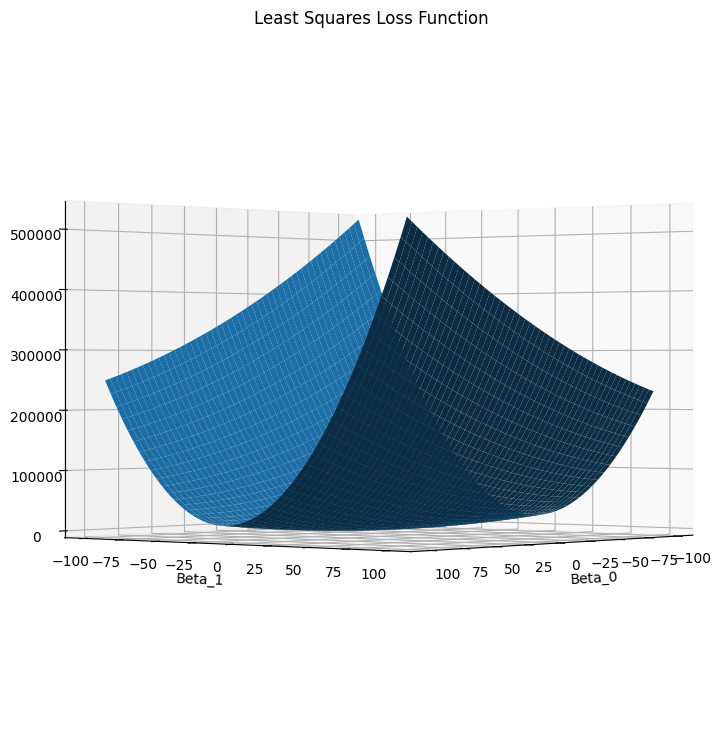

In [ ]:
# @title Plot of Loss Function as a Surface in $\mathbb{R}^3$
# Import libraries
from mpl_toolkits import mplot3d
import numpy as np
import matplotlib.pyplot as plt


# Creating dataset
x = np.outer(np.linspace(-100, 100, 1000), np.ones(1000))
y = x.copy().T # transpose
z = ((2 - x + y)**2 + (5 - x - 3*y)**2 + (10 - x - 5*y)**2)

# Creating figure
fig = plt.figure(figsize =(14, 9))
ax = plt.axes(projection ='3d')

# Creating plot
ax.plot_surface(x, y, z)

# show plot
plt.xlabel("Beta_0")
plt.ylabel("Beta_1")
plt.title("Least Squares Loss Function")
ax.view_init(0, 40)
plt.show()

### Gradient Descent

The previous section illustrates two key concepts:

1. Solving for $\boldsymbol{{\beta}}^*$ directly using calculus *involves solving the same system of equations as the least squares solution*. The motivation of a calculus-based approach was to avoid the computational cost of finding an inverse! The approach we used above illustrates that calculus will produce the same solution as last squares but it doesn't actually reduce computational complexity.

2. The optimal solution $\boldsymbol\beta^*$ is located at the bottom of a very (locally) shallow surface.

**Property**. At any fixed location on the surface $f$, the gradient vector $\nabla f$ always *points in the direction of steepest ascent*.

**Question**. If $\nabla f$ points in the direction of steepest ascent what vector points in the direction of *steepest descent*?

<u>[Gradient Descent](https://www.youtube.com/watch?v=qg4PchTECck)</u> is the process of using the gradient vector and a current location on a surface to iteratively search for the lowest point on the surface.



Gradient Descent in high-dimensional space is very sensitive to unscaled data. The fix for this is to standardize the design matrix before training the model.  



### Data Preprocessing: getting $\mathbf{X}$ and $\mathbf{y}$ ready for training.

Data "preprocessing" is whatever steps are necessary to get $\mathbf{X}$ and $\mathbf{y}$ ready for training. You can think of this as roughly what happens in [Step 3 of Importing Datasets](https://colab.research.google.com/drive/1aBoG9pMebCbCCxnIrkLLoodmWsyybnDE#scrollTo=UWZhAdvta_6p) from Lecture 4. Exactly what this entails always depends on the problem you're working on but it usually something like these steps:


1. **Dealing with missing data**. In Python the default way to code missing values is with ```NaN```, which will show up a lot when working with real data sets. There are several standard methods for dealing with missing data, including

* Dropping the lines that have missing data.

* Using the column means to replace the missing data.

* More advanced methods such as using a seperate regression model to estimate the missing values.
2. **Dealing with data types**. We've had to deal with this occasionally in this class and in the real world you can expect to encounter a lot of training errors and work-arounds involving casting depending on how messy the data was when you started.

3. **Standardization**. Sometimes algorithms will struggle with training if your data set isn't standardized. Keep in mind that if you standardize the data your model's parameters will be standardized as well. The advantages are computational efficiency and accuracy; the disadvantages are less interpretability. For the ```babies_linear_model``` we're about to build we can skip this step, which will make the results much easier to interpret. Later in this lecture we'll see an example of why you'd want to (not skip this step) and standardize $\mathbf{X}$ and $\mathbf{y}$ before training your model.




In [ ]:
from sklearn import preprocessing
import numpy as np

X = np.array([[1,-1], [1, 3], [1, 5]])
y = np.array([[2],[5],[10]])

scaler_x = preprocessing.StandardScaler() #construct the scalar object
X_std = np.concatenate((X[:,0:1],scaler_x.fit_transform(X[:,1:])), axis = 1) #deploy and calculate
scaler_y = preprocessing.StandardScaler()
y_std = scaler_y.fit_transform(y)

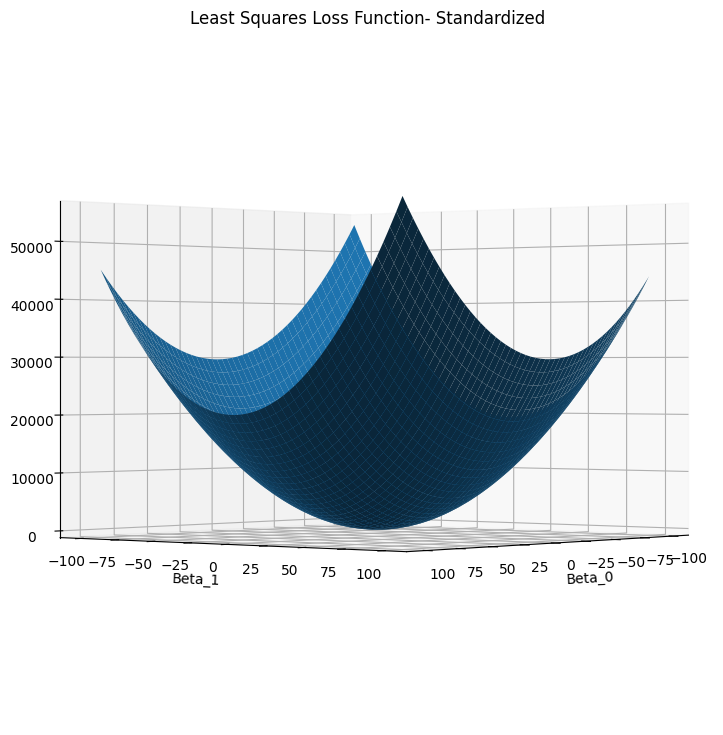

In [ ]:
# @title Plot of Standardized Loss Function as a Surface in $\mathbb{R}^3$
# Import libraries
from mpl_toolkits import mplot3d
import numpy as np
import matplotlib.pyplot as plt


# Creating dataset
x = np.outer(np.linspace(-100, 100, 1000), np.ones(1000))
y = x.copy().T # transpose
z = ((y_std[0,0] - x + X_std[0,1]*y)**2 + (y_std[1,0]  - X_std[1,1]*y)**2 + (y_std[2,0] +x - X_std[2,1]*y)**2) # I slightly perturbed the 1s vector in X for illustration purposes.

# Creating figure
fig = plt.figure(figsize =(14, 9))
ax = plt.axes(projection ='3d')

# Creating plot
ax.plot_surface(x, y, z)

# show plot
plt.xlabel("Beta_0")
plt.ylabel("Beta_1")
plt.title("Least Squares Loss Function- Standardized")
ax.view_init(0, 40)
plt.show()

## 12.3 Logistic Regression Models

Recall: a *categorical* variable takes non-numeric values. Datasets in Python often use ```0```s and ```1```s of type ```int``` to encode these values.

A *Logistic Regression Model* is a transformation of a linear regression model that predicts the probability that a categorical variable will be a "success" (usually encoded as a ```1```)  by fitting an equation of the form:

\begin{align} \hat{p}(x_1, x_2, ... , x_p) = \frac{e^{\hat{\beta}_0 + \hat{\beta}_1x_1 + \hat{\beta}_2x_2 + ... + \hat{\beta}_px_p}}{1 + e^{\hat{\beta}_0 + \hat{\beta}_1x_1 + \hat{\beta}_2x_2 + ... + \hat{\beta}_px_p}}
\end{align}

to the data.

**Question**. Can you find $\boldsymbol{\hat{\beta}}$ by doing least squares?

You can read about how to use scikit-learn to intialize and train these models by reading the documentation on the  [scikit-learn API](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html#).

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving babies.csv to babies.csv


In [ ]:
import pandas as pd

babies = pd.read_csv("babies.csv")
babies.head()

In [ ]:
# NaN values will cause problems during training, let's drop them. Note that we are still in Pandas.

babies = babies.dropna()
babies.head()

In [ ]:
# Construct the design matrix X and the y vector.
import numpy as np

X = babies.to_numpy()[:,1:7]
y = babies.to_numpy()[:,7]
y = y#y.astype(int) # y is supposed to contain binary values but they were encoded in the csv as floats. Change them here.
print(y)

In [ ]:
from sklearn import linear_model

babies_logistic = linear_model.LogisticRegression(solver = "liblinear").fit(X, y)
babies_logistic.n_iter_


In [ ]:
from sklearn import preprocessing
import numpy as np

scaler = preprocessing.StandardScaler() #construct the scalar object
X_std = np.concatenate((scaler.fit_transform(X[:, (0, 1, 3, 4, 5)]), X[:, 2].reshape(X.shape[0], 1)), axis = 1) # Needed to reshape to get Python dimensions to match.

In [ ]:
babies_logistic_std = linear_model.LogisticRegression(solver = "liblinear").fit(X_std, y)
babies_logistic_std.n_iter_

In [ ]:
babies_logistic_std.coef_

In [ ]:
babies_logistic_std.score(X_std, y)